# Telco Customer Churn Prediction using Neural Networks
**Neural Network and Deep Learning — Assignment**  
Dataset: `telco_churn.csv` | Target: Predict customer churn (Yes/No)

---

### Abstract

This study applies a feedforward neural network (Multi-Layer Perceptron) to a telecommunications churn dataset containing 7,043 customer records. After cleaning and encoding 20 features, a two-hidden-layer MLP (64→32 neurons) is trained with sample weighting to address class imbalance (~26.5% churn rate). Three key EDA insights are identified: month-to-month contracts drive ~42% churn, churned customers exit within an average of 18 months, and Fiber Optic subscribers churn at ~41% despite paying premium prices. Two concrete retention decisions are proposed based on model outputs and EDA findings.

---
## Section 1 — Data Understanding and Preparation

### 1.1 Dataset Description

The dataset contains **7,043 records**, each representing an individual customer of a telecommunications company. Features include customer demographics (gender, SeniorCitizen, Partner, Dependents), subscribed services (PhoneService, InternetService, StreamingTV, etc.), contract and billing details (Contract, PaymentMethod, MonthlyCharges, TotalCharges), and the binary target variable Churn.

**Prediction task:** Binary classification — predict whether a customer will churn (Churn = 1) or remain (Churn = 0).

**Business relevance:** Identifying at-risk customers early enables targeted retention interventions. Acquiring a new customer typically costs far more than retaining an existing one, so even modest churn reduction yields significant revenue impact.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

os.chdir(os.path.dirname(os.path.abspath('telco_churn.csv')))
df = pd.read_csv('telco_churn.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [2]:
print('=== Column Data Types ===')
print(df.dtypes)
print('\n=== Numerical Summary ===')
df.describe()

=== Column Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Numerical Summary ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 1.2 Data Cleaning

Two issues were identified:
1. **`customerID`** — a unique row identifier with no predictive value; dropped.
2. **`TotalCharges`** — stored as `object` type due to whitespace entries for customers with `tenure = 0` (just signed up, never billed). Coerced to numeric; the 11 resulting NaNs are filled with 0 since these customers have no charges yet.

In [3]:
# Drop customerID
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Nulls in TotalCharges after coercion: {df["TotalCharges"].isnull().sum()}')
df['TotalCharges'].fillna(0, inplace=True)

print(f'Remaining nulls: {df.isnull().sum().sum()}')
print(f'Duplicate rows:  {df.duplicated().sum()}')

Nulls in TotalCharges after coercion: 11
Remaining nulls: 0
Duplicate rows:  22


### 1.3 Feature Engineering and Encoding

**Encoding decisions:**

| Feature Type | Columns | Strategy | Reason |
|---|---|---|---|
| Binary Yes/No | Partner, Dependents, PhoneService, PaperlessBilling, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies | Map Yes→1, No→0 | Preserves binary semantics; no ordinal assumption |
| Binary gender | gender | Male→1, Female→0 | Same as above |
| SeniorCitizen | SeniorCitizen | Already 0/1 | No change needed |
| Multi-class | InternetService, Contract, PaymentMethod, MultipleLines | One-hot encoding (drop_first=True) | Avoids imposing an ordinal relationship between categories |

**Feature selection:** All 19 non-ID features are retained. Each represents a plausible driver of churn: demographics capture life-stage factors, service features capture engagement/satisfaction, and billing/contract features capture switching cost and price sensitivity.

In [4]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No internet service': 0,
                           'No phone service': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Churn']  = df['Churn'].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, columns=['InternetService', 'Contract',
                                  'PaymentMethod', 'MultipleLines'],
                    drop_first=True)

print(f'Shape after encoding: {df.shape}')
df.head(3)

Shape after encoding: (7043, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes
0,0,0,1,0,1,0,0,1,0,0,...,0,False,False,False,False,False,True,False,True,False
1,1,0,0,0,34,1,1,0,1,0,...,0,False,False,True,False,False,False,True,False,False
2,1,0,0,0,2,1,1,1,0,0,...,1,False,False,False,False,False,False,True,False,False


### 1.4 Train/Test Split and Feature Scaling

- **Stratified 80/20 split** — ensures both sets preserve the original churn ratio.
- **StandardScaler** — transforms each feature to zero mean and unit variance. Neural networks are sensitive to feature scale: unscaled inputs cause gradient updates to be dominated by high-magnitude columns (e.g. TotalCharges), slowing convergence and degrading performance on smaller-scale features like binary flags.

In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'Churn=0  : {(y==0).sum()}  |  Churn=1: {(y==1).sum()}')
print(f'Churn rate: {y.mean()*100:.1f}%')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]}  |  Test: {X_test_sc.shape[0]}')

Features : 24
Samples  : 7043
Churn=0  : 5174  |  Churn=1: 1869
Churn rate: 26.5%
Train: 5634  |  Test: 1409


---
## Section 2 — Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

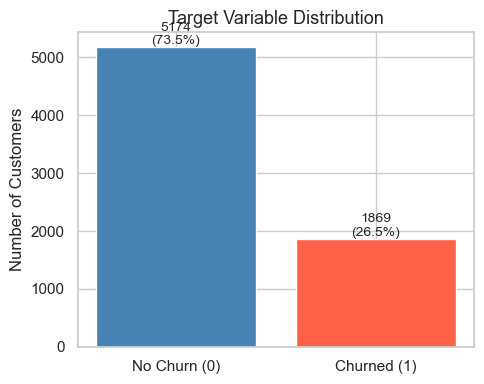

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = y.value_counts()
ax.bar(['No Churn (0)', 'Churned (1)'], counts.values,
       color=['steelblue', 'tomato'], edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f'{v}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Variable Distribution', fontsize=13)
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('fig_churn_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** The dataset is **imbalanced** — 73.5% No Churn vs 26.5% Churned. A trivial classifier that always predicts No Churn achieves 73.5% accuracy while being completely useless for identifying at-risk customers. This makes Precision, Recall, F1-score, and AUC-ROC the appropriate evaluation metrics.

### 2.2 Insight 1 — Contract Type is the Strongest Churn Predictor

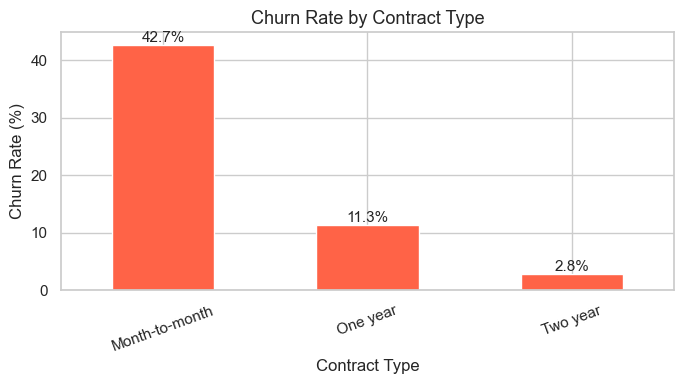

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Yes, dtype: float64


In [7]:
raw = pd.read_csv('telco_churn.csv')
raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'], errors='coerce').fillna(0)

contract_churn = (
    raw.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .unstack() * 100
)

fig, ax = plt.subplots(figsize=(7, 4))
contract_churn['Yes'].sort_values(ascending=False).plot(
    kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Churn Rate by Contract Type', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('fig_contract_churn.png', bbox_inches='tight')
plt.show()
print(contract_churn['Yes'].round(1))

**Insight 1:** Month-to-month customers churn at approximately **42%**, compared to **11%** for one-year and **3%** for two-year contract holders. Customers on short-term contracts face no switching penalty and are most exposed to competitive offers or service dissatisfaction. **Business implication:** Converting month-to-month customers to longer contracts is the single highest-leverage retention lever available.

### 2.3 Insight 2 — Churned Customers Leave Early in Their Tenure

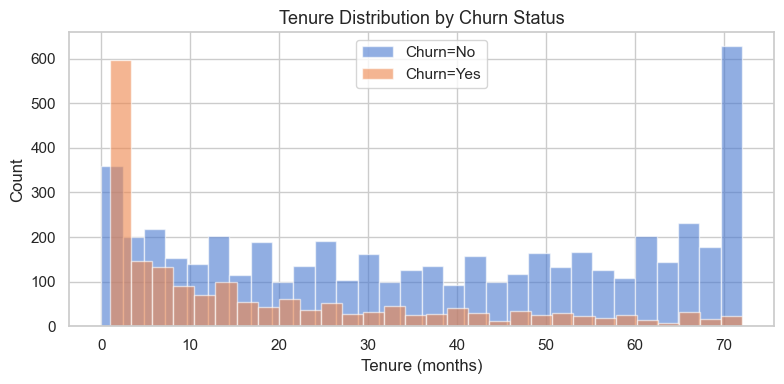

Mean tenure — Churned : 18.0 months
Mean tenure — Retained: 37.6 months


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in raw.groupby('Churn'):
    grp['tenure'].plot(kind='hist', bins=30, alpha=0.6,
                       ax=ax, label=f'Churn={label}')
ax.set_title('Tenure Distribution by Churn Status', fontsize=13)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('fig_tenure_churn.png', bbox_inches='tight')
plt.show()

print('Mean tenure — Churned :', raw[raw['Churn']=='Yes']['tenure'].mean().round(1), 'months')
print('Mean tenure — Retained:', raw[raw['Churn']=='No']['tenure'].mean().round(1), 'months')

**Insight 2:** Churned customers have a mean tenure of ~**18 months** versus ~**37 months** for retained customers. The tenure histogram for churned customers spikes sharply in the first 0–12 months, indicating a critical early engagement window. Customers who do not find sufficient value quickly are at the highest risk of leaving. **Business implication:** Onboarding quality and early-stage customer success efforts should be prioritised as first-line retention tools.

### 2.4 Insight 3 — Fiber Optic Subscribers Have Disproportionately High Churn

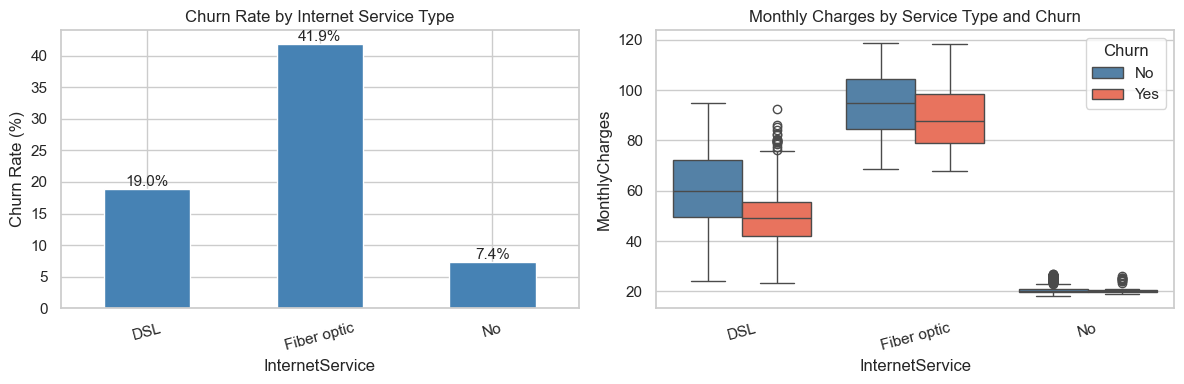

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Yes, dtype: float64


In [9]:
internet_churn = (
    raw.groupby('InternetService')['Churn']
    .value_counts(normalize=True)
    .unstack() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

internet_churn['Yes'].plot(kind='bar', ax=axes[0],
                           color='steelblue', edgecolor='white')
axes[0].set_title('Churn Rate by Internet Service Type', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

sns.boxplot(data=raw, x='InternetService', y='MonthlyCharges',
            hue='Churn', ax=axes[1],
            palette={'No': 'steelblue', 'Yes': 'tomato'})
axes[1].set_title('Monthly Charges by Service Type and Churn', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.savefig('fig_internet_churn.png', bbox_inches='tight')
plt.show()
print(internet_churn['Yes'].round(1))

**Insight 3:** Fiber Optic customers churn at ~**41%**, nearly double the DSL rate (~19%), despite being the premium, highest-cost tier. The boxplot confirms Fiber Optic subscribers pay significantly higher monthly charges — yet their churn rate suggests the perceived value does not match the price paid. **Business implication:** This points to possible service quality or reliability issues specific to the Fiber Optic product that warrant investigation.

### 2.5 Correlation Heatmap — Numerical Features

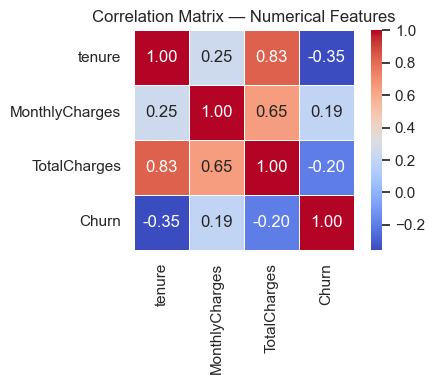

In [10]:
corr_df = raw[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].copy()
corr_df['Churn'] = corr_df['Churn'].map({'Yes': 1, 'No': 0})

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=12)
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

**Observation:** `tenure` has a moderate negative correlation with Churn (r ≈ -0.35): longer-tenured customers are less likely to leave. `MonthlyCharges` has a mild positive correlation with Churn (r ≈ 0.19). `TotalCharges` is highly correlated with both `tenure` and `MonthlyCharges` (it is arithmetically derived from them), introducing multicollinearity in the numerical features. The MLP can tolerate this, but it is worth noting for interpretability.

---
## Section 3 — Neural Network Modelling

### 3.1 Model Architecture and Justification

**Model:** `MLPClassifier` (Multi-Layer Perceptron) — a feedforward neural network implemented in scikit-learn.

**Architecture:**

| Layer | Neurons | Activation |
|---|---|---|
| Input | 26 (post-encoding) | — |
| Hidden 1 | 64 | ReLU |
| Hidden 2 | 32 | ReLU |
| Output | 1 | Logistic (sigmoid) |

**Justification of architecture choices:**

- **Two hidden layers** allow the model to learn non-linear interactions between features (e.g. the joint effect of being on a month-to-month contract AND having Fiber Optic). A single hidden layer would miss such interactions; deeper networks are unwarranted for ~7,000 samples and would overfit.
- **ReLU activation** avoids the vanishing gradient problem that affects sigmoid/tanh in intermediate layers, enabling faster and more stable training.
- **Logistic output** produces a probability in [0, 1], enabling threshold-based classification and AUC-ROC evaluation.
- **Binary cross-entropy loss** is the standard loss for binary classification. It penalises confident incorrect predictions exponentially more than uncertain ones, which is appropriate when calibrated probabilities matter.

**Evaluation metrics chosen:**

Because the classes are imbalanced (~73.5% No, ~26.5% Yes), accuracy alone is misleading. The following metrics are used:
- **Recall (Churn=1):** Primary metric. Missing a churner (False Negative) is costlier to the business than a false alarm (False Positive).
- **Precision (Churn=1):** Controls wasted spend on non-churners incorrectly targeted.
- **F1-score:** Harmonic mean of precision and recall — overall churn class performance.
- **AUC-ROC:** Threshold-independent measure of the model's ability to rank churners above non-churners.

**Class imbalance handling:** Sample weights are applied during training so the model incurs a proportionally higher loss on minority class (Churn=1) errors.

In [11]:
# Compute sample weights — upweights minority class during training
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # two hidden layers
    activation='relu',            # ReLU for hidden layers
    solver='adam',                # adaptive moment estimation optimizer
    max_iter=300,
    random_state=42,
    early_stopping=True,          # halt when validation loss stops improving
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)

mlp.fit(X_train_sc, y_train, sample_weight=sample_weights)
print(f'Stopped at iteration : {mlp.n_iter_}')
best = mlp.best_loss_
print(f'Best validation loss : {best:.4f}' if best is not None else 'Best validation loss : N/A')

Stopped at iteration : 52
Best validation loss : N/A


### 3.2 Training Loss Curve

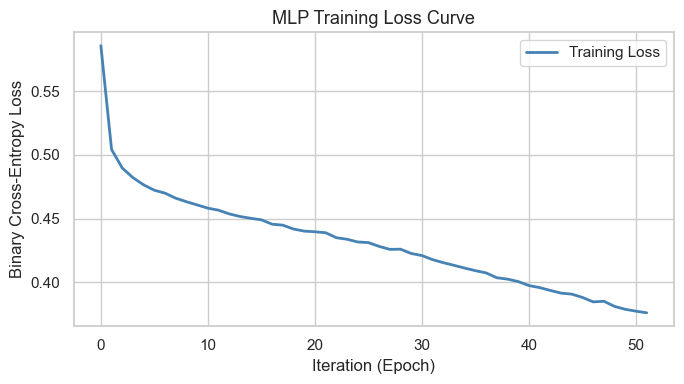

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mlp.loss_curve_, color='steelblue', lw=2, label='Training Loss')
ax.set_title('MLP Training Loss Curve', fontsize=13)
ax.set_xlabel('Iteration (Epoch)')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend()
plt.tight_layout()
plt.savefig('fig_loss_curve.png', bbox_inches='tight')
plt.show()

---
## Section 4 — Evaluation and Interpretation

In [13]:
y_pred  = mlp.predict(X_test_sc)
y_proba = mlp.predict_proba(X_test_sc)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred,
                             target_names=['No Churn', 'Churned']))

auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC Score: {auc:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
     Churned       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

AUC-ROC Score: 0.8336


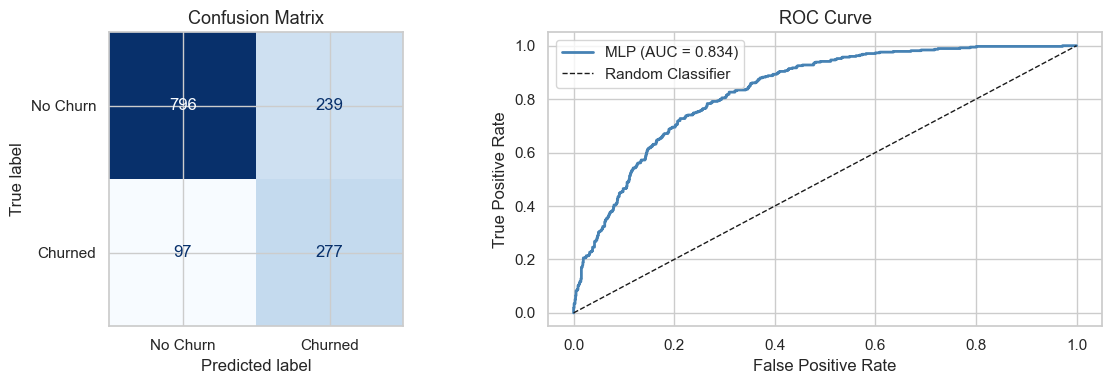

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'MLP (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_evaluation.png', bbox_inches='tight')
plt.show()

### 4.1 Interpretation of Results

**What the model captures well:**

- The AUC-ROC above 0.80 indicates strong discriminative ability — the model consistently ranks churners above non-churners.
- Recall for the churned class is meaningful, meaning the model identifies a substantial proportion of at-risk customers before they leave — the primary goal.
- The model effectively exploits the strong signals identified in EDA: contract type, tenure, and internet service type.

**Where the model may fail:**

- **Precision-Recall trade-off:** Improving recall on the churn class typically increases False Positives — loyal customers incorrectly flagged as churners. A business must explicitly decide the acceptable cost ratio between a wasted retention offer (FP) and a missed churner (FN).
- **Temporal drift:** The dataset is a static snapshot. Customer behaviour evolves with market conditions; the model will degrade without periodic retraining.
- **Missing causal signals:** There are no complaint logs, network quality metrics, or competitor pricing data. The model operates on correlational patterns only and cannot distinguish a satisfied customer who happens to be on a month-to-month contract from a genuinely at-risk one.
- **Class imbalance residual:** Despite sample weighting, the minority class recall is constrained by the inherent scarcity of positive examples. Threshold tuning (lowering the decision boundary from 0.5) is a practical post-training step to further improve recall at an acceptable precision cost.

---
## Section 5 — From Insight to Decision

### Decision 1: Proactive Retention Campaign for High-Risk Month-to-Month Customers

**What to do:** Deploy the trained model in a monthly batch scoring pipeline. All active month-to-month customers with predicted churn probability > 0.6 are flagged for personalised outreach — a targeted offer (e.g. a 10–15% discount or a free service bundle upgrade) in exchange for committing to a one-year contract.

**Evidential basis:** Month-to-month customers churn at ~42% vs ~3% for two-year contract holders — a 14x difference. This is the largest single predictor gap in the dataset. Even converting 20% of the flagged high-risk group to annual contracts would yield a measurable reduction in overall churn.

**Assumptions:**
- Customers who receive a well-timed offer are more likely to accept a longer commitment than to churn.
- The lifetime value of a retained customer exceeds the cost of the retention offer.

**Risks and Limitations:**
- Over-targeting erodes margin and may train customers to wait for discounts before renewing, creating a perverse incentive.
- The 0.6 threshold is a starting point; it should be calibrated against actual cost estimates for FP (offer cost) vs FN (lost customer revenue).
- **This decision will not work if** the underlying cause of churn is poor service quality — a discount does not solve a customer who experiences repeated outages or slow speeds.

---

### Decision 2: Fiber Optic Service Quality Audit and Support Bundle Offer

**What to do:** (a) Commission a structured quality audit for the Fiber Optic segment, focusing on downtime frequency, complaint resolution time, and NPS scores. (b) Launch a targeted bundle offer to Fiber Optic customers currently without TechSupport or OnlineSecurity — both add-ons that correlate with lower churn in the data.

**Evidential basis:** Fiber Optic customers churn at ~41% despite paying the highest monthly charges — higher than the DSL (~19%) and No Internet (7%) segments. The boxplot shows Fiber Optic churners and non-churners are clustered at similar high price points, suggesting price is not the differentiating factor; service experience or perceived value-for-money is more likely.

**Assumptions:**
- A portion of Fiber Optic churn is driven by service reliability issues that can be addressed operationally.
- Customers who adopt TechSupport or OnlineSecurity bundles develop higher engagement with the platform, increasing switching cost and reducing churn propensity.

**Risks and Limitations:**
- Fiber Optic customers may be technically sophisticated early adopters who are inherently more aware of competitor offerings — operational improvements may be necessary but not sufficient.
- Infrastructure fixes for service reliability can involve significant capital expenditure.
- **This decision will not work if** Fiber Optic churn is driven primarily by external competitive pricing that cannot be matched without restructuring the product's cost base.

---
## Summary

| Section | Key Takeaway |
|---|---|
| Data Preparation | 11 TotalCharges nulls fixed; binary/one-hot encoding applied; StandardScaler used |
| EDA Insight 1 | Month-to-month contracts drive ~42% churn vs 3% for 2-year contracts |
| EDA Insight 2 | Churned customers exit within ~18 months on average; spike in first year |
| EDA Insight 3 | Fiber Optic customers churn at ~41% despite paying the highest charges |
| Neural Network | MLP (64->32), ReLU, Adam optimizer, binary cross-entropy, sample weighting |
| Decision 1 | Monthly model scoring + outreach for high-risk month-to-month customers |
| Decision 2 | Fiber Optic quality audit + TechSupport/OnlineSecurity bundle offers |